# Teste assíncrono — Cientista de Dados, maio/2026

## **Candidato:** Victor Soares Setubal Wingler Lucas

# Carregamento do Dataset

 O primeiro passo é carregar o Dataset. Utilizarei a biblioteca `pandas` que é amplamente utilizada no tratamento de dados.

In [2]:
import pandas as pd

debitos_data = pd.read_csv('debitos_municipais_ficticios_vitoria_es.csv', sep=';', encoding='latin1')
bairros_data = pd.read_csv('bairros_referencia.csv', encoding='utf-8')

Vale ressaltar que o arquivo principal possui separadores ';' e a codificação foi alterada conforme necessário.

# Inspeção inicial

Agora, pode-se fazer:

- Uma inspeção de algumas linhas das tabelas
- Tamanho dos datasets
- Os nomes das colunas
- Tipo das colunas
- Presença de duplicação

## Inspeção de algumas linhas das tabelas

In [3]:
debitos_data.head()

,idRegistroDebito,idContribuinte,tipoContribuinte,cpfCnpjFicticio,idImovel,inscricaoMunicipal,tipoTributo,bairro,regionalAdministrativa,municipio,...,atividadeEconomica,setorEconomico,porteEstimado,regimeTributario,empregosEstimados,beneficioFiscal,indicadorVulnerabilidadeBairro,rendaMediaBairroEstimada,origemCadastro,observacaoCadastro
0,DEB20260000001,C0018821,PF,796.539.219-02,IMO0040265,233.506.2438.6,IPTU,Praia Do Canto,V - Praia do Canto,Vitória,...,NaN,NaN,PF,Pessoa Física,0,Não,0.140,"R$ 9.800,00",Dívida Ativa,registro migrado de sistema antigo
1,DEB20260000002,C0034442,PJ,03.233.701/6527-30,IMO0064196,121.934.7565.2,ISS,PRAIA DO SUÁ,V - Praia do Canto,Vitória,...,Associação,Outros,Médio,MEI,228,Não,0.127,9238.08,Importação legado,NaN
2,DEB20260000003,C0012873,PJ,95.136.762/0847-32,NaN,855.540.6295.2,ISS,BENTO FERREIRA,III - Jucutuquara,Vitória,...,Serviços de alimentação,Serviços,MEI,Simples Nacional,2,Não,0.576,3758.75,Dívida Ativa,NaN
3,DEB20260000004,C0001823,PF,23674577607,IMO0060934,764.728.4940.7,IPTU,PRAIA DO CANTO,V - Praia do Canto,Vitória,...,NaN,NaN,PF,Pessoa Física,0,Não,0.140,9800.00,Portal do Contribuinte,NaN
4,DEB20260000005,C0035666,PJ,55.508.773/5046-43,IMO0000683,177.488.3859.5,IPTU,MORADA DE CAMBURI,IX - Jardim da Penha,NaN,...,Serviços de engenharia,Construção,ME,Lucro Presumido,12,Não,0.238,7145.02,Importação legado,NaN


Já é possível observar a presença de alguns campos ausentes e inconsistência na formatação do campo cpfCnpjFicticio.

In [4]:
bairros_data.head()

,bairroOficial,regionalAdministrativaOficial,rendaMediaBairroEstimada,indicadorVulnerabilidadeBairro
0,CENTRO,I - Centro,4444.77,0.427
1,DO MOSCOSO,I - Centro,4305.99,0.490
2,FONTE GRANDE,I - Centro,4029.20,0.547
3,ILHA DO PRÍNCIPE,I - Centro,4432.19,0.426
4,PARQUE MOSCOSO,I - Centro,4432.34,0.486


## Tamanho dos datasets

In [5]:
debitos_data.shape

(80000, 37)

In [6]:
bairros_data.shape

(80, 4)

## Nome das colunas e tipo das colunas

In [7]:
debitos_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   idRegistroDebito                80000 non-null  object
 1   idContribuinte                  80000 non-null  object
 2   tipoContribuinte                80000 non-null  object
 3   cpfCnpjFicticio                 79766 non-null  object
 4   idImovel                        63251 non-null  object
 5   inscricaoMunicipal              80000 non-null  object
 6   tipoTributo                     80000 non-null  object
 7   bairro                          79016 non-null  object
 8   regionalAdministrativa          78406 non-null  object
 9   municipio                       78850 non-null  object
 10  tipoImovel                      80000 non-null  object
 11  usoImovel                       79438 non-null  object
 12  areaConstruidaM2                79806 non-null

Assim, conseguimos ver a presença de campos ausentes e de que alguns campos devem ser tratados para se tornarem um tipo específico, como por exemplo campo de valores que deveriam ser float.

In [8]:
bairros_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 4 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   bairroOficial                   80 non-null     object 
 1   regionalAdministrativaOficial   80 non-null     object 
 2   rendaMediaBairroEstimada        80 non-null     float64
 3   indicadorVulnerabilidadeBairro  80 non-null     float64
dtypes: float64(2), object(2)
memory usage: 2.6+ KB


Esse dataset demonstra consistência em todas as linhas e nos tipos das colunas.

## Presença de duplicação

Agora vamos verificar se há linhas duplicadas

In [9]:
debitos_data.duplicated().sum()

np.int64(656)

# Limpeza de Dados

O próximo passo é lidar com linhhas duplicadas e linhas com campos ausentes que devem ser removidas:

## Linhas duplicadas

Como visto anteriormente, há a presença de 656 linhas exatamente iguais duplicadas. Logo, não faz sentido mantê-las.

In [10]:
debitos_data = debitos_data.drop_duplicates()

## Campos ausentes



- `valorDebitoOriginal`: se esse campo estiver faltante não é possível realizar análise em cima da dívida, logo perde-se o valor da linha específica. Assim, optou-se por remover as linhas as quais não possuem tal campo preenchido.

In [11]:
debitos_data = debitos_data.dropna(subset=["valorDebitoOriginal"])

# Padronização e Tratamento de Dados

O próximo passo é padrozinar campos como datas, campos com valores e outros.

## Campos com valores

Os campos que envolvem valores: `valorVenal`, `areaConstruidaM2`,`valorDebitoOriginal`, `valorMultaJuros`, `valorPago` e `rendaMediaBairroEstimada` devem ser tratados e transformados para float para facilitação da realização de operações matemáticas usando esses campos. Campos vazios em `valorPago` e `valorMultaJuros` foram preenchidos com 0, considerando-se como se não tivesse multa e nenhum valor tivesse sido pago.

In [12]:
import pandas as pd
import re

def limpar_valores(x):
    if pd.isnull(x):
        return None

    x = str(x)

    # remove símbolo de moeda e espaços
    x = re.sub(r"[^\d,.-]", "", x)

    # se tiver vírgula e ponto → assumir: ponto = milhar, vírgula = decimal
    if "," in x and "." in x:
        x = x.replace(".", "").replace(",", ".")

    # se só tiver vírgula → decimal
    elif "," in x:
        x = x.replace(",", ".")

    # se só tiver ponto → já está ok
    try:
        return float(x)
    except:
        return None

cols = ["valorDebitoOriginal", "valorMultaJuros", "valorPago", "valorVenal", "rendaMediaBairroEstimada", "areaConstruidaM2"]

for c in cols:
    debitos_data[c] = debitos_data[c].apply(limpar_valores)

# valorPago ausente -> 0
debitos_data["valorPago"] = (
    debitos_data["valorPago"]
    .fillna(0)
)

# valorMultaJuros ausente -> 0
debitos_data["valorMultaJuros"] = (
    debitos_data["valorMultaJuros"]
    .fillna(0)
)

O campo `indicadorVulnerabilidadeBairro` pelo o que pesquisei representa um indicador que varia entre 0 e 1. Entretanto, alguns campos estão fora desse intervalo. Desse modo, optou-se por tornar o campo nulo naqueles que estão fora do intervalo exigido. Além disso, fez-se o tratamento para que o campo se torna-se float.

In [13]:
col = "indicadorVulnerabilidadeBairro"

debitos_data[col] = (
    debitos_data[col]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

debitos_data[col] = pd.to_numeric(debitos_data[col], errors="coerce")

debitos_data.loc[(debitos_data[col] < 0) | (debitos_data[col] > 1), col] = None

## Datas

Agora é necessário realizar o tratamento do campo `dataVencimento` e `dataUltimoPagamento`

In [14]:
cols = ["dataVencimento", "dataUltimoPagamento"]

for col in cols:
    base = debitos_data[col].astype(str).str.strip()

    data1 = pd.to_datetime(base, errors="coerce")  # ISO
    data2 = pd.to_datetime(base, errors="coerce", dayfirst=True)  # BR

    # formato americano (MM/DD/YYYY)
    data3 = pd.to_datetime(base, format="%m/%d/%Y", errors="coerce")

    # tentativa de substituir - por /
    data4 = pd.to_datetime(
        base.str.replace("-", "/", regex=False),
        errors="coerce",
        dayfirst=True
    )

    debitos_data[col] = data1.fillna(data2).fillna(data3).fillna(data4)

/tmp/ipykernel_1447/2179755460.py:7: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  data2 = pd.to_datetime(base, errors="coerce", dayfirst=True)  # BR
/tmp/ipykernel_1447/2179755460.py:13: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  data4 = pd.to_datetime(


Considerou-se o formato em que o dia/mês/ano que é o padrão no Brasil.

In [15]:
debitos_data["dataVencimento"].isnull().sum()

np.int64(1900)

Ou seja, 1900 datas de vencimento apresentaram formato inválido, mesmo levando em conta diferentes formatações diferentes para ela.

## Padronização de textos

Para facilitar na realização de buscas, ordenação e outros deve-se padronizar texto em maiúsculas ou minúsculas.

No caso, optei por manter todos em maiúsculo.

In [16]:
to_upper = ["tipoTributo", "tipoContribuinte", "bairro", "municipio", "situacaoPagamento", "regionalAdministrativa", "tipoImovel", "usoImovel", "atividadeEconomica",
            "setorEconomico", "porteEstimado", "regimeTributario", "beneficioFiscal", "origemCadastro", "canalContato"]
for col in to_upper:
  debitos_data[col] = (
    debitos_data[col]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", " ", regex=True)  # remove espaços duplicados no meio da string
)

## Padronização de Categorias

### Situação de Pagamento
 Primeiramente é necessário ver quais opções únicas temos na tabela para fazer a conversão adequada para cada um dos tipos de situação de pagamento.

In [17]:
debitos_data["situacaoPagamento"].unique()

array(['DÍVIDA ATIVA', 'PARCELADO', 'EM ABERTO', 'PAGO', 'PARC.',
       'QUITADO', 'ABERTO', 'DIVIDA ATIVA', 'ATRASADO'], dtype=object)

Com isso, podemos formular o mapeamento para cada um dos tipos:

In [18]:
map_pagamento = {
    "EM ABERTO": "EM ABERTO",
    "ATRASADO": "ATRASADO",
    "DIVIDA ATIVA": "DÍVIDA ATIVA",
    "DÍVIDA ATIVA": "DÍVIDA ATIVA",
    "PAGO": "PAGO",
    "QUITADO": "QUITADO",
    "PARCELADO": "PARCELADO",
    "PARC.": "PARCELADO"
}

debitos_data["situacaoPagamento"] = debitos_data["situacaoPagamento"].map(map_pagamento)

In [19]:
debitos_data["situacaoPagamento"].unique()

array(['DÍVIDA ATIVA', 'PARCELADO', 'EM ABERTO', 'PAGO', 'QUITADO', nan,
       'ATRASADO'], dtype=object)

### Tipo de Tributo

In [20]:
debitos_data["tipoTributo"].unique()

array(['IPTU', 'ISS'], dtype=object)

Já está padronizado corretamente.

### Tipo de Contribuinte

In [21]:
debitos_data["tipoContribuinte"].unique()

array(['PF', 'PJ'], dtype=object)

Já está padronizado corretamente também.

### Setor econômico

In [22]:
debitos_data["setorEconomico"].unique()

array(['NAN', 'OUTROS', 'SERVIÇOS', 'CONSTRUÇÃO', 'COMÉRCIO', 'SERVICOS',
       'INDÚSTRIA', 'CONSTRUCAO', 'N/I', 'COMERCIO'], dtype=object)

Assim como na situação de pagamento será necessário fazer o mapeamento nesse caso:

In [23]:
map_economico = {
    "OUTROS": "OUTROS",
    "SERVIÇOS": "SERVIÇOS",
    "SERVICOS": "SERVIÇOS",
    "CONSTRUÇÃO": "CONSTRUÇÃO",
    "CONSTRUCAO": "CONSTRUÇÃO",
    "N/I": "N/I",
    "COMERCIO": "COMÉRCIO",
    "COMÉRCIO": "COMÉRCIO",
    "INDÚSTRIA": "INDÚSTRIA",
    "INDUSTRIA": "INDÚSTRIA"
}

debitos_data["setorEconomico"] = debitos_data["setorEconomico"].map(map_economico)

In [24]:
debitos_data["setorEconomico"].unique()

array([nan, 'OUTROS', 'SERVIÇOS', 'CONSTRUÇÃO', 'COMÉRCIO', 'INDÚSTRIA',
       'N/I'], dtype=object)

### Porte Estimado

In [25]:
debitos_data["porteEstimado"].unique()

array(['PF', 'MÉDIO', 'MEI', 'ME', 'EPP', 'GRANDE', 'MICROEMPRESA',
       'MEDIO', 'PEQUENO PORTE', 'NAN'], dtype=object)

Logo, deverá ser feito o mapeamento também:

In [26]:
map_porte = {
    "PF": "PF",
    "MÉDIO": "MÉDIO",
    "MEI": "MEI",
    "MICROEMPRESA": "ME",
    "ME": "ME",
    "GRANDE": "GRANDE",
    "MEDIO": "MÉDIO",
    "PEQUENO PORTE": "EPP",
    "EPP": "EPP",
}

debitos_data["porteEstimado"] = debitos_data["porteEstimado"].map(map_porte)

In [27]:
debitos_data["porteEstimado"].unique()

array(['PF', 'MÉDIO', 'MEI', 'ME', 'EPP', 'GRANDE', nan], dtype=object)

### Canal de Contato

In [28]:
debitos_data["canalContato"].unique()

array(['WHATSAPP', 'PRESENCIAL', 'SMS', 'CORREIO', 'EMAIL', 'E-MAIL',
       'TELEFONE', 'NAN', 'ZAP'], dtype=object)

Dessa forma, deverá ser feito o mapeamento novamente:

In [29]:
map_contato = {
    "WHATSAPP": "WHATSAPP",
    "ZAP": "WHATSAPP",
    "SMS": "SMS",
    "CORREIO": "CORREIO",
    "EMAIL": "E-MAIL",
    "E-MAIL": "E-MAIL",
    "TELEFONE": "TELEFONE"
}

debitos_data["canalContato"] = debitos_data["canalContato"].map(map_contato)

In [30]:
debitos_data["canalContato"].unique()

array(['WHATSAPP', nan, 'SMS', 'CORREIO', 'E-MAIL', 'TELEFONE'],
      dtype=object)

## Tratamento do campo `cpfCnpjFicticio`

Optou-se por fazer uma limpeza simples nesse campo, sem validação, pelo fato de que esse campo deveria ser validado durante a aquisição dos dados. Assim, optou-se por manter somente números para esse campo.

In [31]:
debitos_data["cpfCnpjFicticio"] = (
    debitos_data["cpfCnpjFicticio"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
)

Assim, evita-se duplicidade pela presença/ausência de caracteres não-numéricos.

## Tratamento dos campo `telefone` e `email` - Meios de Contato

Por se tratarem de campos de contato, que em uma análise não serviria como parâmetro de comparação, optou-se por não realizar validação ou tratamento desses campos. Vale ressaltar, que assim como pdf, são campo que devem ser validados durante a coleta dos dados. Entretanto, optou-se pela padronização do campo `telefoneDisponivel`.

In [32]:
debitos_data["telefoneDisponivel"].unique()

array(['Sim', 'Não', 'true', '1', 'S'], dtype=object)

In [33]:
map_telefone = {
    "Sim": "SIM",
    "S": "SIM",
    "1": "SIM",
    "true": "SIM",
    "Não": "NAO"
}

debitos_data["telefoneDisponivel"] = debitos_data["telefoneDisponivel"].map(map_telefone)

In [34]:
debitos_data["telefoneDisponivel"].unique()

array(['SIM', 'NAO'], dtype=object)

## Padronização Nome de Bairros, Regionais e Indicadores

Primeiramente vamos criar uma função de padronização das strings para retirar acentos, espaços duplicados e garantir que a comparação seja feita corretamente.

In [35]:
import unicodedata
import pandas as pd

def padronizar_texto(s):
    if pd.isnull(s):
        return None

    s = str(s).strip().lower()

    # remove acentos
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))

    # remove espaços duplicados
    s = " ".join(s.split())

    return s

Aplica-se essa padronização em ambas as bases e cria-se uma nova coluna padronizada.

In [36]:
debitos_data["bairro_pad"] = (
    debitos_data["bairro"]
    .apply(padronizar_texto)
)

In [37]:
bairros_data["bairro_pad"] = (
    bairros_data["bairroOficial"]
    .apply(padronizar_texto)
)

Agora faremos o merge a partir dessa coluna padronizada.

In [38]:
merged = debitos_data.merge(
    bairros_data[
        [
            "bairro_pad",
            "bairroOficial",
            "regionalAdministrativaOficial",
            "rendaMediaBairroEstimada",
            "indicadorVulnerabilidadeBairro"
        ]
    ],
    on="bairro_pad",
    how="left",
    suffixes=("", "_ref")
)

Feito o merge podemos fazer a substituição pelos nomes e valores da referência:

In [39]:
merged["bairro"] = (
    merged["bairroOficial"]
    .fillna(merged["bairro"])
)

In [40]:
merged["regionalAdministrativa"] = (
    merged["regionalAdministrativaOficial"]
    .fillna(merged["regionalAdministrativa"])
)

In [41]:
merged["rendaMediaBairroEstimada"] = (
    merged["rendaMediaBairroEstimada_ref"]
    .fillna(merged["rendaMediaBairroEstimada"])
)

merged["indicadorVulnerabilidadeBairro"] = (
    merged["indicadorVulnerabilidadeBairro_ref"]
    .fillna(merged["indicadorVulnerabilidadeBairro"])
)

Vale ressaltar que caso não tenha ocorrido correspondência manteve-se os valores da tabela principal.

Agora pode-se verificar a taxa de correspondência, ou seja, quantos bairros de fato foram correspondidos entre a tabela principal e a de referência.

In [42]:
print("Taxa de correspondência:", 100*round(merged["bairroOficial"].notnull().mean(),2), "%")

Taxa de correspondência: 96.0 %


Ou seja, conseguimos validar o nome de 96% dos bairros e regionais, assim como os índices. Isso demonstra uma diminuição excelente em uma possível verificação manual.

Podemos analisar alguns dos casos que não obtiveram correspondência para entender o motivo:

In [43]:
merged[merged["bairroOficial"].isnull()]["bairro"].value_counts().head(20)

,count
bairro,
NAN,972
JARDIM LIMOEIRO,191
GLÓRIA,191
PRAIA DA COSTA,180
CAMPO GRANDE,180
JARDIM AMÉRICA,178
ITAPOÃ,177
LARANJEIRAS,172
COQUEIRAL DE ITAPARICA,159


Com isso, é possível verificar casos em que os bairros não estão na tabela de referência, abreviações, erro no nome do bairro, campos ausentes.

Além disso, é possível verificar quantos bairros efetivamente seriam necessários de se analisar manualmente (pois há muitos que não obtiveram correspondência mas possuem o mesmo nome):

In [44]:
import numpy as np

print("Quantidade de bairros que exigem análise manual: ",merged[merged["bairroOficial"].isnull()]["bairro"].unique().size-1)

Quantidade de bairros que exigem análise manual:  33


Logo, somente 33 bairros deveriam ser analisados manualmente, o que é uma tarefa definitivamente tranquila.

In [45]:
debitos_data = merged.drop(columns=[
    "bairro_pad",
    "bairroOficial",
    "regionalAdministrativaOficial",
    "rendaMediaBairroEstimada_ref",
    "indicadorVulnerabilidadeBairro_ref"
])

# Cálculo de Indicadores e Análise

Agora será realizado o cálculo de alguns indicadores como solicitado:

Os inadimplentes são aqueles que não possuem acordo e não pagaram a dívida, logo:

In [46]:
inadimplentes = debitos_data[
    debitos_data["situacaoPagamento"]
    .isin([
        "EM ABERTO",
        "DÍVIDA ATIVA",
        "ATRASADO"
    ])
].copy()

É imprescindível realizar o cálculo da dívida efetiva de cada um dos inadimplentes:

In [47]:
inadimplentes["valorEmAberto"] = (
    inadimplentes["valorDebitoOriginal"] -
    inadimplentes["valorPago"]+
    inadimplentes["valorMultaJuros"]
)

Função para manter a formatação BR:

In [48]:
def formatar_reais(valor):
    if pd.isnull(valor):
        return None

    valor = f"R$ {valor:,.2f}"

    return (
        valor
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

## Valor Total da Dívida Inadimplente

In [49]:
print("Total de dívida dos inadimplentes: ", formatar_reais(inadimplentes["valorEmAberto"].sum()))

Total de dívida dos inadimplentes:  R$ 538.309.055,70


## Número de Contribuintes Inadimplentes

In [50]:
print("Número de inadimplentes: ", inadimplentes["idContribuinte"].nunique())

Número de inadimplentes:  31891


## Número de Registros Inadimplentes

In [51]:
print("Número de registros inadimplentes: ", len(inadimplentes))

Número de registros inadimplentes:  49395


## Valores Médio e Mediano das Dívidas

In [52]:
print("Valor médio das dívidas inadimplentes: ", formatar_reais(inadimplentes["valorEmAberto"].mean()))
print("Valor mediano das dívidas inadimplentes: ", formatar_reais(inadimplentes["valorEmAberto"].median()))

Valor médio das dívidas inadimplentes:  R$ 10.898,05
Valor mediano das dívidas inadimplentes:  R$ 4.248,55


Ou seja, como a média é muito maior que a mediana é possível concluir que há uma quantidade pequena de dívidas com valores muito altos que causam isso.

## Distribuição por faixa de valores

In [53]:
bins = [
    0,
    1000,
    5000,
    10000,
    50000,
    100000,
    float("inf")
]

labels = [
    "0-1 mil",
    "1-5 mil",
    "5-10 mil",
    "10-50 mil",
    "50-100 mil",
    "100 mil+"
]

inadimplentes["faixaDivida"] = pd.cut(
    inadimplentes["valorEmAberto"],
    bins=bins,
    labels=labels
)

inadimplentes["faixaDivida"].value_counts().sort_index()

,count
faixaDivida,
0-1 mil,3505
1-5 mil,23763
5-10 mil,11116
10-50 mil,9465
50-100 mil,690
100 mil+,386


Assim, conseguimos observar que é uma parcela pequena que se encontra com dívidas superiores a 50 mil, mas que causa o aumento na média.

## Concentração da dívida

Podemos analisar o top 10% que possuem o maior valor em aberto e compará-los com a quantidade total de dívida

In [54]:
limite_top10 = inadimplentes["valorEmAberto"].quantile(0.9)

valor_top10 = inadimplentes.loc[
    inadimplentes["valorEmAberto"] >= limite_top10,
    "valorEmAberto"
].sum()

print("Porcentagem da dívida total que o top 10% acumula: ", round(100* valor_top10 / inadimplentes["valorEmAberto"].sum(),2), "%")

Porcentagem da dívida total que o top 10% acumula:  59.4 %


## Contato Válido

Optou-se por uma verificação simples: verificar a variável tratada anteriormente `telefoneDisponivel` ou se há um email válido verificando através da presença do @ (não é a verificação ideal).

In [55]:
telefone_valido = (inadimplentes["telefoneDisponivel"] == "SIM")
email_valido = inadimplentes["email"].str.contains("@", na=False)

contato_valido = (telefone_valido | email_valido)

taxa_contato = contato_valido.mean()

print("Taxa de inadimplentes com meio de contato válido: ",round(100*taxa_contato,2))

Taxa de inadimplentes com meio de contato válido:  89.33


## Distribuição por Bairro

Assim, podemos observar os 10 bairros com maior número de inadimplentes a seguir:

In [56]:
inadimplentes["bairro"].value_counts().head(10)

,count
bairro,
CENTRO,2081
JARDIM CAMBURI,2043
PRAIA DO CANTO,2034
JARDIM DA PENHA,2025
ENSEADA DO SUÁ,1990
MARUÍPE,1834
BENTO FERREIRA,1730
SÃO PEDRO,1710
SANTO ANTÔNIO,1706


Podemos também calcular o total somado das inadimplências em cada bairro e mostrar o top 10 novamente:

In [57]:
inadimplentes.groupby("bairro")["valorEmAberto"].sum().sort_values(ascending=False).head(10)

,valorEmAberto
bairro,
JARDIM DA PENHA,32625539.20
PARQUE INDUSTRIAL,30762373.18
PRAIA DO CANTO,30699853.27
ENSEADA DO SUÁ,24612830.11
JARDIM CAMBURI,21588181.16
AEROPORTO,18481821.48
CENTRO,17469066.33
ILHA DO FRADE,16927658.88
GOIABEIRAS,15975517.13


Curiosamente o bairro com maior quantidade de inadimplentes encontra-se em sétimo lugar quando vamos levar em consideração os valores.

## Distribuição por Regional

Pode-se fazer uma análise similar a feita anteriormente com relação aos bairros:

In [58]:
inadimplentes["regionalAdministrativa"].value_counts().head(10)

,count
regionalAdministrativa,
V - Praia do Canto,8219
I - Centro,6425
III - Jucutuquara,5653
IV - Maruípe,5108
IX - Jardim da Penha,5046
II - Santo Antônio,4991
VII - São Pedro,4365
VI - Goiabeiras,4191
VIII - Jardim Camburi,3438


In [59]:
inadimplentes.groupby("regionalAdministrativa")["valorEmAberto"].sum().sort_values(ascending=False).head(10)

,valorEmAberto
regionalAdministrativa,
V - Praia do Canto,1.233380e+08
IX - Jardim da Penha,7.203589e+07
VI - Goiabeiras,5.651431e+07
I - Centro,5.261105e+07
VIII - Jardim Camburi,5.235055e+07
III - Jucutuquara,5.170809e+07
II - Santo Antônio,4.047619e+07
IV - Maruípe,3.974691e+07
VII - São Pedro,3.240980e+07


Neste caso, conservou-se que a maior quantidade de inadimplmentes está na região com maior inadimplência.

## Separação IPTU e ISS

Podemos realizar uma comparação entre as inadimplências entre as duas classes: IPTU que está relacionado a imóveis e ISS que está relacionado a atividade econômica.

### Número de inadimplências

In [60]:
inadimplentes["tipoTributo"].value_counts()

,count
tipoTributo,
IPTU,35578
ISS,13817


Há prevalência de IPTU sob ISS na quantidade.

### Soma das inadimplências

In [61]:
iptu = inadimplentes[inadimplentes["tipoTributo"] == "IPTU"]

iss = inadimplentes[inadimplentes["tipoTributo"] == "ISS"]

print("Total IPTU: ", formatar_reais(iptu["valorEmAberto"].sum()))
print("Total ISS: ", formatar_reais(iss["valorEmAberto"].sum()))

Total IPTU:  R$ 278.119.067,87
Total ISS:  R$ 260.189.987,83


Apesar de se ter praticamente o triplo do número de inadimplências a soma da uma diferença percentual pequena entre os dois.

## Histograma com os valores de débito

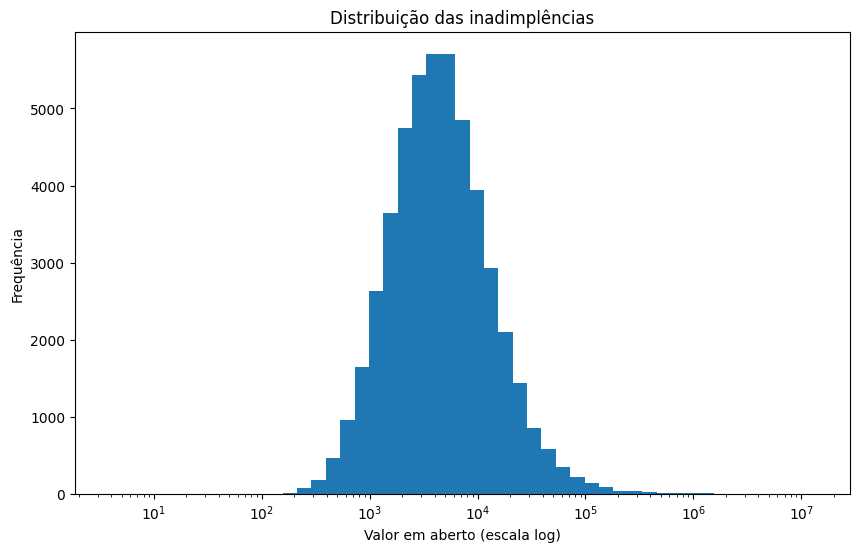

In [62]:
import numpy as np
import matplotlib.pyplot as plt

valores = inadimplentes.loc[
    inadimplentes["valorEmAberto"] > 0,
    "valorEmAberto"
]

bins = np.logspace(
    np.log10(valores.min()),
    np.log10(valores.max()),
    50
)

plt.figure(figsize=(10,6))

plt.hist(valores, bins=bins)

plt.xscale("log")

plt.xlabel("Valor em aberto (escala log)")
plt.ylabel("Frequência")
plt.title("Distribuição das inadimplências")

plt.show()

Foi necessário utilizar a escala logarítimica devido a assimetria e a presença de valores elevados (outilers). A inadimplência aumenta de forma muito exponencial e exige que seja aplicado tal transformação para melhor visualização dos dados.

## Correlação entre Vulnerabilidade e Renda nos Bairros

In [63]:
cols = ["indicadorVulnerabilidadeBairro", "rendaMediaBairroEstimada"]

#garantir valores numéricos
bairros_data[cols] = bairros_data[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

#apagar colunas vazias
dados_corr = bairros_data.dropna(
    subset=[
        "indicadorVulnerabilidadeBairro",
        "rendaMediaBairroEstimada"
    ]
)

#cálculo da correlação
corr = dados_corr[
    "rendaMediaBairroEstimada"
].corr(
    dados_corr["indicadorVulnerabilidadeBairro"]
)

print(corr)

-0.9006633209354848


Pode-se observar uma forte correlação entre os dados de maneira que: Quanto maior a renda média, menor a vulnerabilidade social.

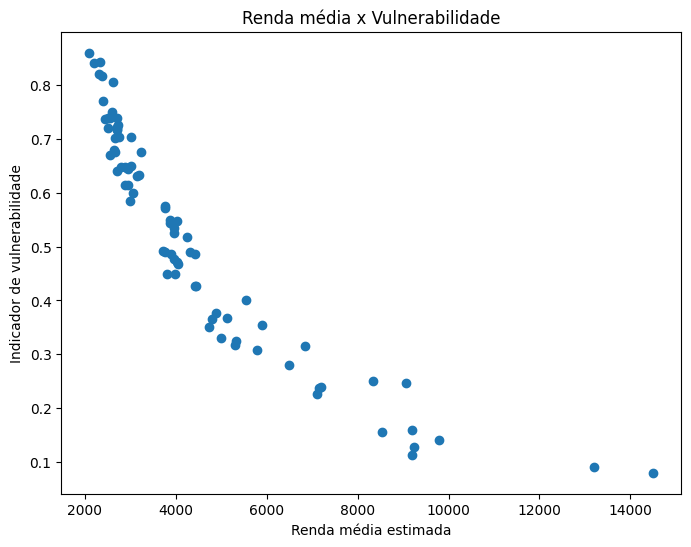

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    dados_corr["rendaMediaBairroEstimada"],
    dados_corr["indicadorVulnerabilidadeBairro"]
)

plt.xlabel("Renda média estimada")
plt.ylabel("Indicador de vulnerabilidade")
plt.title("Renda média x Vulnerabilidade")

plt.show()

O diagrama de dispersão anterior demonstra justamente isso: A medida que aumenta-se a renda média diminui-se o indicador de vulnerabilidade.

# Registro de Uso de IA

Utilizei IA para as seguintes situações:

- Dúvidas quanto a sintaxe python circunstânciais.
- Confirmação na tomada de decisão em alguns casos, como quanto a: a escolha de como tratar determinado campo da tabela de dados (como o campo `cpfCnpjFicticio`) e pipeline de limpeza dos dados.


# Download do Dataset Tratado

Por fim, podemos realizar o download do dataset tratado:

In [65]:
debitos_data.to_csv("debitos_tratados.csv", index=False, sep=';', encoding='utf-8-sig')